<a href="https://colab.research.google.com/github/mdanmek/nida-dads-notes/blob/main/dads5001-data-tools/project/eda/05_construction_storytelling_visuals_2569.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# จากข้อมูลจัดซื้อจัดจ้างสู่รายการตรวจสอบลำดับแรก

Notebook นี้เป็น **presentation layer** ของโครงการ DADS5001 โดยอ่านผลลัพธ์จาก Notebook 02–04 แล้วสร้าง visual ตามลำดับเรื่อง ไม่คำนวณนิยาม scope หรือ criteria ใหม่

ลำดับเรื่องมี 9 ช่วง:

1. เรามีข้อมูลอะไร
2. เมื่อสำรวจงานก่อสร้างทั้งหมด เราพบอะไร
3. การกระจายวงเงินบริเวณ 500,000 บาทมีอะไรสะดุดตา
4. รายการใกล้เพดานสัมพันธ์กับวิธีจัดซื้อใด
5. จากข้อค้นพบ จึงกำหนดขอบเขตศึกษา Pattern
6. Pattern 1: คู่หน่วยงาน–ผู้รับจ้างใดมีรายการใกล้เพดานเกิดซ้ำ
7. Pattern 2: ผู้รับจ้างรายใดครองงานในหน่วยงานสูง
8. Pattern 1 และ Pattern 2 ซ้อนทับกันอย่างไร
9. คู่หน่วยงาน–ผู้รับจ้างใดควรเปิดเอกสารก่อน

ผลลัพธ์เป็นรายการสำหรับตรวจสอบต่อ ไม่ใช่หลักฐานการทุจริตหรือการแบ่งซื้อแบ่งจ้าง


In [2]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
from pathlib import Path
from textwrap import shorten

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import Circle, FancyBboxPatch, FancyArrowPatch

# ดาวน์โหลดฟอนต์ภาษาไทยสำหรับ Matplotlib
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
fm.fontManager.addfont('thsarabunnew-webfont.ttf')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')


## 1. เปิดผลลัพธ์จาก Notebook 02–04

Notebook 05 ใช้ไฟล์ที่ผ่านการเตรียมข้อมูลและสร้าง flag แล้ว หากไฟล์ไม่ครบ ให้ Run all Notebook 02 → 03 → 04 ก่อน


In [4]:
processed_dir = Path(
    '/content/drive/MyDrive/learning/dads/dads5001/'
    'project_1_dads5001/dataset/procurement/'
    'egp-contract/processed'
)

figure_dir = processed_dir.parents[3] / 'figure'
figure_dir.mkdir(parents=True, exist_ok=True)

contract_path = processed_dir / 'construction_contract_supplier_study_scope_2569.csv'
flags_path = processed_dir / 'construction_contract_review_indicators_2569.csv'
repeated_pairs_path = processed_dir / 'repeated_near_500k_agency_supplier_2569.csv'
dependence_path = processed_dir / 'agency_supplier_dependence_2569.csv'
priority_path = processed_dir / 'priority_review_contracts_2569.csv'

required_paths = [
    contract_path,
    flags_path,
    repeated_pairs_path,
    dependence_path,
    priority_path
]

missing_paths = [path for path in required_paths if not path.exists()]

if missing_paths:
    missing_text = '\n'.join(str(path) for path in missing_paths)
    raise FileNotFoundError(
        'ไม่พบไฟล์ผลลัพธ์ต่อไปนี้ กรุณา Run all Notebook 02–04 ก่อน:\n'
        f'{missing_text}'
    )

contract_data = pd.read_csv(contract_path, low_memory=False)
contract_flags = pd.read_csv(flags_path, low_memory=False)
repeated_pairs = pd.read_csv(repeated_pairs_path, low_memory=False)
pattern2_pairs = pd.read_csv(dependence_path, low_memory=False)
priority_contracts = pd.read_csv(priority_path, low_memory=False)

file_summary = pd.DataFrame({
    'ข้อมูล': [
        'รายการสัญญา–ผู้รับจ้างก่อสร้าง',
        'รายการพร้อม flag',
        'คู่ที่เข้า Pattern 1',
        'คู่ที่เข้า Pattern 2',
        'รายการตรวจสอบลำดับแรก'
    ],
    'จำนวนแถว': [
        len(contract_data),
        len(contract_flags),
        len(repeated_pairs),
        len(pattern2_pairs),
        len(priority_contracts)
    ]
})

display(file_summary)


,ข้อมูล,จำนวนแถว
0,รายการสัญญา–ผู้รับจ้างก่อสร้าง,179716
1,รายการพร้อม flag,179716
2,คู่ที่เข้า Pattern 1,1580
3,คู่ที่เข้า Pattern 2,79
4,รายการตรวจสอบลำดับแรก,161


In [5]:
project_id_column = 'รหัสโครงการ'
contract_column = 'เลขที่สัญญา'
contract_value_column = 'วงเงินงบประมาณในสัญญา (บาท)'
method_column = 'ชื่อวิธีการจัดซื้อจัดจ้าง'
agency_column = 'ชื่อหน่วยงาน'
province_column = 'จังหวัด'
supplier_id_column = 'เลขประจำตัวนิติบุคคล 13 หลัก'
supplier_name_column = 'ชื่อผู้ชนะการเสนอราคา'
scope_column = 'อยู่ในขอบเขตตรวจรูปแบบ'

flag_columns = [
    'flag_pattern_1',
    'flag_pattern_2',
    'priority_review'
]

for column in flag_columns:
    contract_flags[column] = (
        contract_flags[column]
        .astype('boolean')
        .fillna(False)
    )

study_data = contract_data.loc[contract_data[scope_column]].copy()
near_ceiling_data = study_data.loc[
    study_data[contract_value_column].between(490000, 500000)
].copy()

print(f'รายการสัญญาก่อสร้างทั้งหมด: {len(contract_data):,}')
print(f'รายการในขอบเขตศึกษา: {len(study_data):,}')
print(f'รายการใกล้เพดาน: {len(near_ceiling_data):,}')
print(f'รายการตรวจสอบลำดับแรก: {len(priority_contracts):,}')


รายการสัญญาก่อสร้างทั้งหมด: 179,716
รายการในขอบเขตศึกษา: 136,122
รายการใกล้เพดาน: 20,200
รายการตรวจสอบลำดับแรก: 161


## 2. Visual theme

ใช้สีตามความหมายเดียวกันทุกภาพ:

- น้ำเงิน: ข้อมูลหลัก
- ส้ม: จุดใกล้เพดานหรือสิ่งที่ต้องสนใจ
- แดง: รายการตรวจสอบลำดับแรก
- เทา: ข้อมูลเปรียบเทียบ


In [6]:
FIG_SIZE = (12, 6.75)
EXPORT_DPI = 180
COLORS = {
    'primary': '#365F7D',
    'secondary': '#6F8FA6',
    'highlight': '#D9822B',
    'risk': '#B5473C',
    'neutral': '#98A2B3',
    'light': '#E4E7EC',
    'text': '#344054',
    'muted': '#667085',
    'background': '#FFFFFF'
}

plt.rcParams.update({
    'font.family': 'TH Sarabun New',
    'font.size': 12,
    'text.color': COLORS['text'],
    'axes.labelcolor': COLORS['text'],
    'axes.titlecolor': COLORS['text'],
    'axes.titlesize': 17,
    'axes.titleweight': 'semibold',
    'axes.titlelocation': 'left',
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.color': COLORS['muted'],
    'ytick.color': COLORS['muted'],
    'axes.edgecolor': COLORS['light'],
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True,
    'grid.color': COLORS['light'],
    'grid.linewidth': 0.8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'svg.fonttype': 'none',
    'axes.unicode_minus': False
})


def add_subtitle(ax, text):
    ax.text(
        0,
        1.01,
        text,
        transform=ax.transAxes,
        fontsize=11,
        color=COLORS['muted'],
        ha='left',
        va='bottom'
    )


def clean_axis(ax, grid_axis='x'):
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis=grid_axis, color=COLORS['light'])
    ax.grid(axis='y' if grid_axis == 'x' else 'x', visible=False)


def save_figure(fig, stem):
    png_path = figure_dir / f'{stem}.png'
    svg_path = figure_dir / f'{stem}.svg'

    fig.savefig(
        png_path,
        dpi=EXPORT_DPI,
        bbox_inches='tight',
        facecolor='white'
    )
    fig.savefig(
        svg_path,
        bbox_inches='tight',
        facecolor='white'
    )

    print(f'Saved: {png_path}')
    print(f'Saved: {svg_path}')


## Story 1 — เรามีข้อมูลอะไร

เริ่มจากข้อมูล e-GP ปีงบประมาณ 2569 จำนวน 3,964,924 รายการ เลือกเฉพาะประเภทโครงการ “จ้างก่อสร้าง” 180,079 รายการ แล้วตัดรหัสผู้รับจ้างที่ขึ้นต้นด้วย `D` จำนวน 363 รายการ เหลือข้อมูลวิเคราะห์ระดับสัญญา–ผู้รับจ้าง 179,716 รายการ

จำนวนโครงการไม่ซ้ำคำนวณจาก `รหัสโครงการ` ส่วนจำนวนแถววิเคราะห์ใช้ grain `รหัสโครงการ + รหัสผู้รับจ้าง + เลขที่สัญญา` จึงไม่จำเป็นต้องเท่ากัน


In [7]:
source_record_count = 3964924
construction_record_count = 180079
excluded_d_count = 363
analysis_record_count = len(contract_data)
unique_project_count = contract_data[project_id_column].nunique()

data_journey = pd.DataFrame({
    'ขั้นตอน': [
        'ข้อมูล e-GP ทั้งหมด',
        'เลือกประเภทจ้างก่อสร้าง',
        'ตัดรหัสผู้รับจ้างขึ้นต้นด้วย D',
        'ข้อมูลสัญญา–ผู้รับจ้างที่ใช้วิเคราะห์',
        'รหัสโครงการไม่ซ้ำในข้อมูลวิเคราะห์'
    ],
    'จำนวน': [
        source_record_count,
        construction_record_count,
        excluded_d_count,
        analysis_record_count,
        unique_project_count
    ],
    'หน่วย': [
        'รายการ',
        'รายการ',
        'รายการที่ตัดออก',
        'รายการสัญญา–ผู้รับจ้าง',
        'โครงการ'
    ]
})

display(data_journey)


,ขั้นตอน,จำนวน,หน่วย
0,ข้อมูล e-GP ทั้งหมด,3964924,รายการ
1,เลือกประเภทจ้างก่อสร้าง,180079,รายการ
2,ตัดรหัสผู้รับจ้างขึ้นต้นด้วย D,363,รายการที่ตัดออก
3,ข้อมูลสัญญา–ผู้รับจ้างที่ใช้วิเคราะห์,179716,รายการสัญญา–ผู้รับจ้าง
4,รหัสโครงการไม่ซ้ำในข้อมูลวิเคราะห์,178978,โครงการ


## Story 2 — เมื่อสำรวจงานก่อสร้างทั้งหมด เราพบอะไร

เริ่มสำรวจข้อมูลก่อสร้างทั้งหมดก่อนกำหนดขอบเขต Pattern โดยดูทั้งการกระจายตามช่วงวงเงินและวิธีจัดซื้อจัดจ้าง ภาพนี้ทำหน้าที่ชี้ว่าบริเวณใดควรขยายดูต่อ


Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig05_01_construction_overview.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig05_01_construction_overview.svg


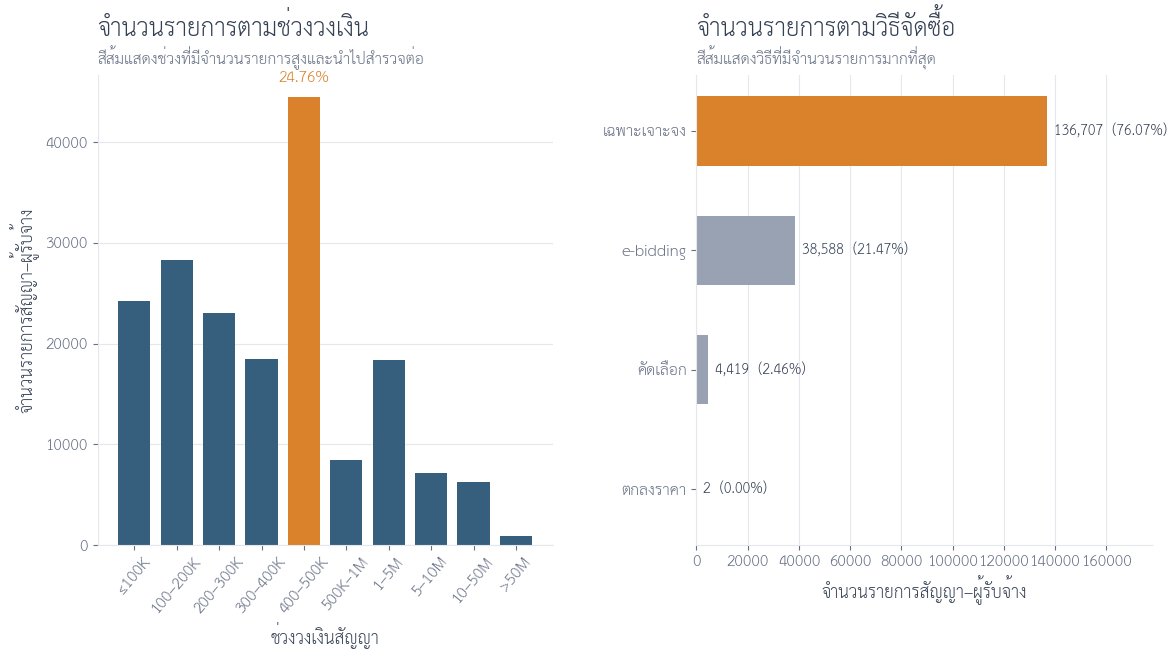

In [8]:
budget_bins = [
    -np.inf,
    100000,
    200000,
    300000,
    400000,
    500000,
    1000000,
    5000000,
    10000000,
    50000000,
    np.inf
]
budget_labels = [
    '≤100K',
    '100–200K',
    '200–300K',
    '300–400K',
    '400–500K',
    '500K–1M',
    '1–5M',
    '5–10M',
    '10–50M',
    '>50M'
]

budget_band = pd.cut(
    contract_data[contract_value_column],
    bins=budget_bins,
    labels=budget_labels,
    right=True,
    include_lowest=True
)

budget_summary = (
    budget_band
    .value_counts(sort=False)
    .rename('จำนวนรายการ')
    .reset_index()
    .rename(columns={contract_value_column: 'ช่วงวงเงิน', 'index': 'ช่วงวงเงิน'})
)
budget_summary['สัดส่วน (%)'] = (
    budget_summary['จำนวนรายการ'] /
    budget_summary['จำนวนรายการ'].sum() * 100
)

method_overview = (
    contract_data[method_column]
    .fillna('ไม่ระบุ')
    .value_counts()
    .rename('จำนวนรายการ')
    .reset_index()
    .rename(columns={'index': method_column})
)
method_overview['สัดส่วน (%)'] = (
    method_overview['จำนวนรายการ'] /
    method_overview['จำนวนรายการ'].sum() * 100
)
method_overview['วิธีจัดซื้อ'] = (
    method_overview[method_column]
    .replace({
        'ประกวดราคาอิเล็กทรอนิกส์ (e-bidding)': 'e-bidding'
    })
)

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
ax_budget, ax_method = axes

budget_colors = [
    COLORS['highlight'] if label == '400–500K'
    else COLORS['primary']
    for label in budget_summary['ช่วงวงเงิน'].astype(str)
]
budget_bars = ax_budget.bar(
    budget_summary['ช่วงวงเงิน'].astype(str),
    budget_summary['จำนวนรายการ'],
    color=budget_colors,
    width=0.76
)
ax_budget.set_title('จำนวนรายการตามช่วงวงเงิน', pad=28)
add_subtitle(ax_budget, 'สีส้มแสดงช่วงที่มีจำนวนรายการสูงและนำไปสำรวจต่อ')
ax_budget.set_xlabel('ช่วงวงเงินสัญญา')
ax_budget.set_ylabel('จำนวนรายการสัญญา–ผู้รับจ้าง')
ax_budget.tick_params(axis='x', rotation=50)
clean_axis(ax_budget, grid_axis='y')

for bar, share, label in zip(
    budget_bars,
    budget_summary['สัดส่วน (%)'],
    budget_summary['ช่วงวงเงิน'].astype(str)
):
    if label == '400–500K':
        ax_budget.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + budget_summary['จำนวนรายการ'].max() * 0.025,
            f'{share:.2f}%',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='semibold',
            color=COLORS['highlight']
        )

method_plot = method_overview.sort_values('จำนวนรายการ')
method_colors = [
    COLORS['highlight'] if method == 'เฉพาะเจาะจง'
    else COLORS['neutral']
    for method in method_plot['วิธีจัดซื้อ']
]
method_bars = ax_method.barh(
    method_plot['วิธีจัดซื้อ'],
    method_plot['จำนวนรายการ'],
    color=method_colors,
    height=0.58
)
method_labels = [
    f'{count:,.0f}  ({share:.2f}%)'
    for count, share in zip(
        method_plot['จำนวนรายการ'],
        method_plot['สัดส่วน (%)']
    )
]
ax_method.bar_label(
    method_bars,
    labels=method_labels,
    padding=5,
    fontsize=10,
    color=COLORS['text']
)
ax_method.set_title('จำนวนรายการตามวิธีจัดซื้อ', pad=28)
add_subtitle(ax_method, 'สีส้มแสดงวิธีที่มีจำนวนรายการมากที่สุด')
ax_method.set_xlabel('จำนวนรายการสัญญา–ผู้รับจ้าง')
ax_method.set_ylabel('')
ax_method.set_xlim(0, method_plot['จำนวนรายการ'].max() * 1.30)
clean_axis(ax_method, grid_axis='x')

fig.tight_layout(w_pad=3)
save_figure(fig, 'fig05_01_construction_overview')
plt.show()


## Story 3 — การกระจายวงเงินบริเวณ 500,000 บาทมีอะไรสะดุดตา

จากภาพรวมพบว่าช่วง 400,000–500,000 บาทมีจำนวนรายการสูง จึงขยายเฉพาะช่วง 400,000–550,000 บาท เพื่อดูรูปทรงของข้อมูลบริเวณ 500,000 บาทโดยไม่ให้รายการมูลค่าสูงบดบัง


Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig05_02_contract_distribution_around_500k.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig05_02_contract_distribution_around_500k.svg


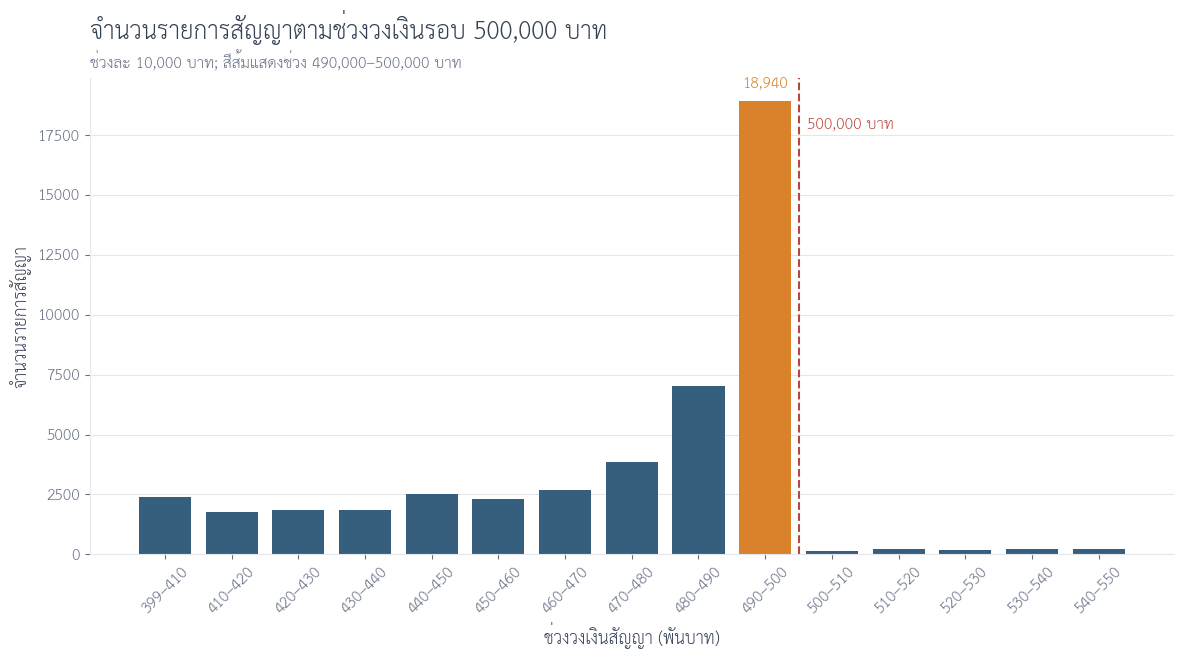

In [9]:
focus_data = contract_data.loc[
    contract_data[contract_value_column].between(400000, 550000)
].copy()

bin_edges = np.arange(400000, 560000, 10000)
focus_data['ช่วงวงเงิน'] = pd.cut(
    focus_data[contract_value_column],
    bins=bin_edges,
    right=True,
    include_lowest=True
)

band_counts = (
    focus_data['ช่วงวงเงิน']
    .value_counts(sort=False)
    .rename('จำนวนรายการ')
    .reset_index()
)

band_counts['label'] = [
    f'{int(interval.left / 1000):,}–{int(interval.right / 1000):,}'
    for interval in band_counts['ช่วงวงเงิน']
]

band_counts['ใกล้เพดาน'] = [
    interval.left >= 490000 and interval.right <= 500000
    for interval in band_counts['ช่วงวงเงิน']
]

colors = np.where(
    band_counts['ใกล้เพดาน'],
    COLORS['highlight'],
    COLORS['primary']
)

fig, ax = plt.subplots(figsize=FIG_SIZE)

bars = ax.bar(
    band_counts['label'],
    band_counts['จำนวนรายการ'],
    color=colors,
    width=0.78
)

for bar, value, highlighted in zip(
    bars,
    band_counts['จำนวนรายการ'],
    band_counts['ใกล้เพดาน']
):
    if highlighted:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + band_counts['จำนวนรายการ'].max() * 0.02,
            f'{value:,.0f}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='semibold',
            color=COLORS['highlight']
        )

ax.axvline(
    9.5,
    color=COLORS['risk'],
    linewidth=1.5,
    linestyle='--'
)
ax.text(
    9.62,
    ax.get_ylim()[1] * 0.90,
    '500,000 บาท',
    color=COLORS['risk'],
    fontsize=11,
    va='center'
)

ax.set_title('จำนวนรายการสัญญาตามช่วงวงเงินรอบ 500,000 บาท', pad=28)
add_subtitle(ax, 'ช่วงละ 10,000 บาท; สีส้มแสดงช่วง 490,000–500,000 บาท')
ax.set_xlabel('ช่วงวงเงินสัญญา (พันบาท)')
ax.set_ylabel('จำนวนรายการสัญญา')
ax.tick_params(axis='x', rotation=45)
clean_axis(ax, grid_axis='y')

fig.tight_layout()
save_figure(fig, 'fig05_02_contract_distribution_around_500k')
plt.show()


## Story 4 — รายการใกล้เพดานสัมพันธ์กับวิธีจัดซื้อใด

เมื่อพบการกระจุกในช่วง 490,000–500,000 บาท ขั้นต่อไปคือดูว่ารายการเหล่านี้เกิดกับวิธีจัดซื้อจัดจ้างใด โดยยังใช้ข้อมูลก่อสร้างทั้งหมดและยังไม่กำหนด scope สำหรับ Pattern


Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig05_03_method_near_500k.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig05_03_method_near_500k.svg


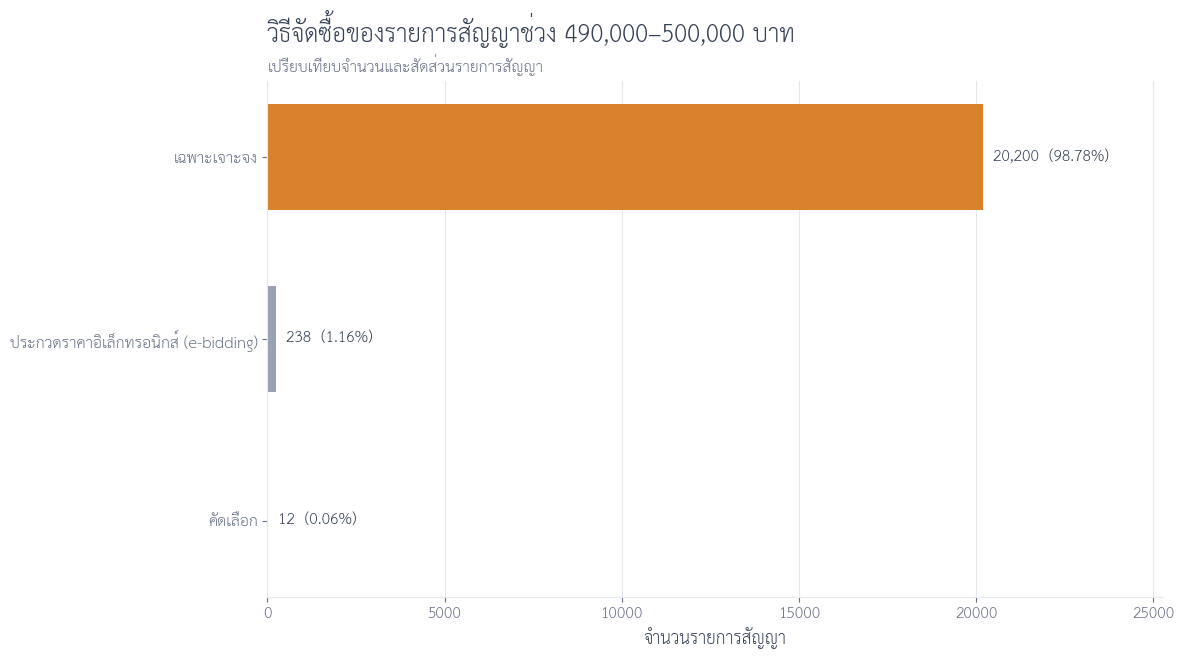

In [10]:
method_summary = (
    contract_data.loc[
        contract_data[contract_value_column].between(490000, 500000)
    ]
    .groupby(method_column, dropna=False)
    .agg({
        contract_column: 'size',
        contract_value_column: 'sum'
    })
    .reset_index()
    .rename(columns={
        contract_column: 'จำนวนรายการ',
        contract_value_column: 'มูลค่ารวม'
    })
)

method_summary['สัดส่วนจำนวน (%)'] = (
    method_summary['จำนวนรายการ'] /
    method_summary['จำนวนรายการ'].sum() * 100
)

method_summary = (
    method_summary
    .sort_values('จำนวนรายการ')
    .reset_index(drop=True)
)

colors = [
    COLORS['highlight']
    if method == 'เฉพาะเจาะจง'
    else COLORS['neutral']
    for method in method_summary[method_column]
]

fig, ax = plt.subplots(figsize=FIG_SIZE)

bars = ax.barh(
    method_summary[method_column],
    method_summary['จำนวนรายการ'],
    color=colors,
    height=0.58
)

labels = [
    f'{count:,.0f}  ({share:.2f}%)'
    for count, share in zip(
        method_summary['จำนวนรายการ'],
        method_summary['สัดส่วนจำนวน (%)']
    )
]

ax.bar_label(
    bars,
    labels=labels,
    padding=7,
    fontsize=11,
    color=COLORS['text']
)

ax.set_title('วิธีจัดซื้อของรายการสัญญาช่วง 490,000–500,000 บาท', pad=28)
add_subtitle(ax, 'เปรียบเทียบจำนวนและสัดส่วนรายการสัญญา')
ax.set_xlabel('จำนวนรายการสัญญา')
ax.set_ylabel('')
ax.set_xlim(0, method_summary['จำนวนรายการ'].max() * 1.25)
clean_axis(ax, grid_axis='x')

fig.tight_layout()
save_figure(fig, 'fig05_03_method_near_500k')
plt.show()


## Story 5 — จากข้อค้นพบ จึงกำหนดขอบเขตศึกษา Pattern

เมื่อพบว่ารายการใกล้เพดานเกือบทั้งหมดใช้วิธีเฉพาะเจาะจง จึงกำหนดขอบเขตศึกษา Pattern เป็น **วิธีเฉพาะเจาะจงและวงเงินไม่เกิน 500,000 บาท** โดยวงกลมแต่ละชั้นแสดง subset ที่ซ้อนกัน และพื้นที่วงกลมสัมพันธ์กับจำนวนรายการ


Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig05_04_pattern_study_scope.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig05_04_pattern_study_scope.svg


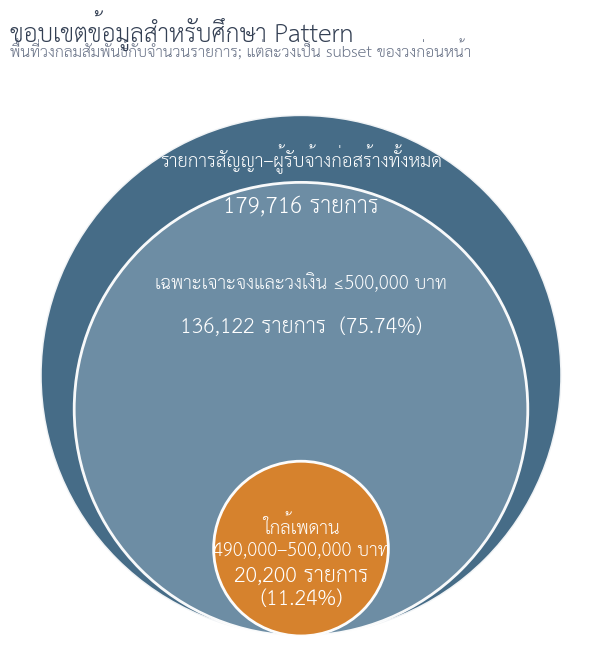

In [11]:
scope_counts = {
    'รายการสัญญา–ผู้รับจ้างก่อสร้างทั้งหมด': len(contract_data),
    'วิธีเฉพาะเจาะจงและวงเงิน ≤500,000 บาท': len(study_data),
    'รายการใกล้เพดาน 490,000–500,000 บาท': len(near_ceiling_data)
}

outer_count = scope_counts['รายการสัญญา–ผู้รับจ้างก่อสร้างทั้งหมด']
study_count = scope_counts['วิธีเฉพาะเจาะจงและวงเงิน ≤500,000 บาท']
near_count = scope_counts['รายการใกล้เพดาน 490,000–500,000 บาท']

outer_radius = 3.0
study_radius = outer_radius * np.sqrt(study_count / outer_count)
near_radius = outer_radius * np.sqrt(near_count / outer_count)

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.set_aspect('equal')
ax.axis('off')

circles = [
    (
        Circle(
            (0, outer_radius),
            outer_radius,
            facecolor=COLORS['primary'],
            edgecolor='white',
            linewidth=2,
            alpha=0.92
        ),
        outer_radius
    ),
    (
        Circle(
            (0, study_radius),
            study_radius,
            facecolor=COLORS['secondary'],
            edgecolor='white',
            linewidth=2,
            alpha=0.96
        ),
        study_radius
    ),
    (
        Circle(
            (0, near_radius),
            near_radius,
            facecolor=COLORS['highlight'],
            edgecolor='white',
            linewidth=2,
            alpha=0.98
        ),
        near_radius
    )
]

for circle, _ in circles:
    ax.add_patch(circle)

ax.text(
    0,
    outer_radius * 1.83,
    'รายการสัญญา–ผู้รับจ้างก่อสร้างทั้งหมด',
    ha='center',
    va='center',
    fontsize=13,
    color='white',
    fontweight='semibold'
)
ax.text(
    0,
    outer_radius * 1.65,
    f'{outer_count:,.0f} รายการ',
    ha='center',
    va='center',
    fontsize=16,
    color='white',
    fontweight='bold'
)

ax.text(
    0,
    study_radius * 1.55,
    'เฉพาะเจาะจงและวงเงิน ≤500,000 บาท',
    ha='center',
    va='center',
    fontsize=13,
    color='white',
    fontweight='semibold'
)
ax.text(
    0,
    study_radius * 1.36,
    f'{study_count:,.0f} รายการ  ({study_count / outer_count * 100:.2f}%)',
    ha='center',
    va='center',
    fontsize=15,
    color='white',
    fontweight='bold'
)

ax.text(
    0,
    near_radius * 1.12,
    'ใกล้เพดาน\n490,000–500,000 บาท',
    ha='center',
    va='center',
    fontsize=13,
    color='white',
    fontweight='semibold',
    linespacing=1.15
)
ax.text(
    0,
    near_radius * 0.55,
    f'{near_count:,.0f} รายการ\n({near_count / outer_count * 100:.2f}%)',
    ha='center',
    va='center',
    fontsize=15,
    color='white',
    fontweight='bold',
    linespacing=1.15
)

ax.set_xlim(-3.35, 3.35)
ax.set_ylim(-0.15, 6.55)
ax.set_title('ขอบเขตข้อมูลสำหรับศึกษา Pattern', pad=18)
add_subtitle(ax, 'พื้นที่วงกลมสัมพันธ์กับจำนวนรายการ; แต่ละวงเป็น subset ของวงก่อนหน้า')

fig.tight_layout()
save_figure(fig, 'fig05_04_pattern_study_scope')
plt.show()


## Story 6 — Pattern 1: คู่หน่วยงาน–ผู้รับจ้างใดมีรายการใกล้เพดานเกิดซ้ำ

ภายในขอบเขตศึกษา เปลี่ยน grain จากรายการเดี่ยวเป็นคู่ **ชื่อหน่วยงาน + ผู้รับจ้าง** แล้วจัดอันดับด้วยจำนวนรายการใกล้เพดาน ส่วน label แสดงสัดส่วนใกล้เพดานภายในคู่เดียวกัน


Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig05_05_pattern1_top10_repeated_pairs.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig05_05_pattern1_top10_repeated_pairs.svg


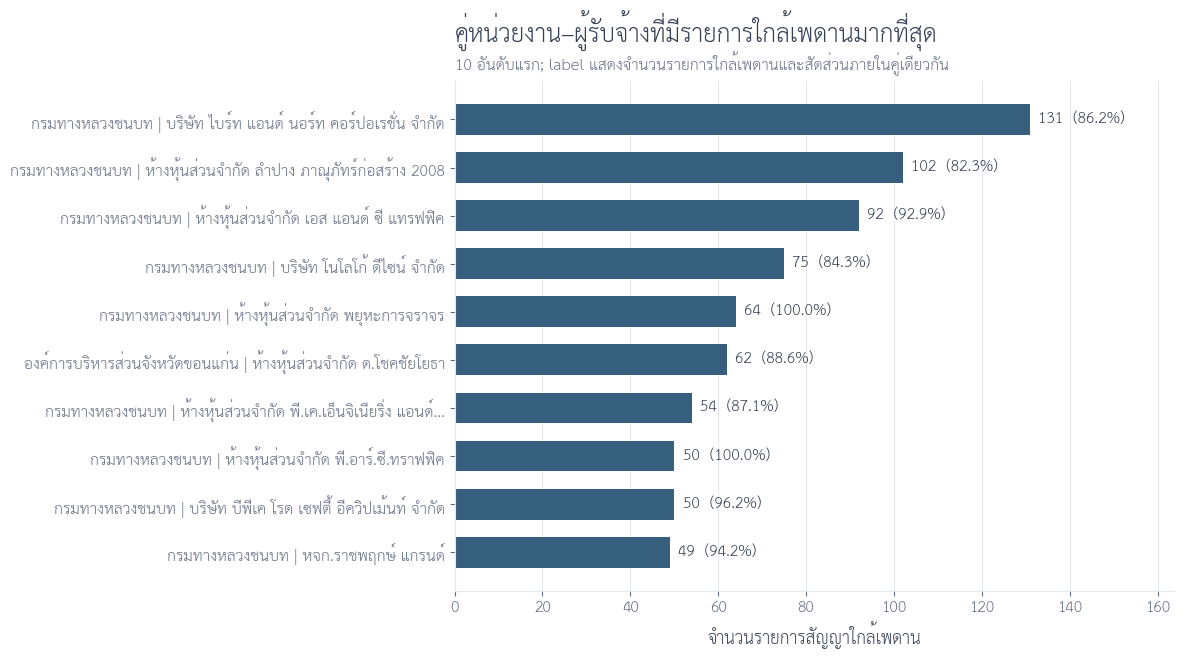

In [12]:
top_repeated_pairs = (
    repeated_pairs
    .sort_values(
        ['จำนวนสัญญาใกล้เพดาน', 'สัดส่วนจำนวนใกล้เพดาน (%)'],
        ascending=False
    )
    .head(10)
    .copy()
)

top_repeated_pairs['คู่หน่วยงาน–ผู้รับจ้าง'] = [
    shorten(
        f'{agency} | {supplier}',
        width=66,
        placeholder='…'
    )
    for agency, supplier in zip(
        top_repeated_pairs[agency_column],
        top_repeated_pairs[supplier_name_column]
    )
]

plot_data = top_repeated_pairs.iloc[::-1]

fig, ax = plt.subplots(figsize=FIG_SIZE)

bars = ax.barh(
    plot_data['คู่หน่วยงาน–ผู้รับจ้าง'],
    plot_data['จำนวนสัญญาใกล้เพดาน'],
    color=COLORS['primary'],
    height=0.64
)

labels = [
    f'{count:,.0f}  ({share:.1f}%)'
    for count, share in zip(
        plot_data['จำนวนสัญญาใกล้เพดาน'],
        plot_data['สัดส่วนจำนวนใกล้เพดาน (%)']
    )
]

ax.bar_label(
    bars,
    labels=labels,
    padding=6,
    fontsize=11,
    color=COLORS['text']
)

ax.set_title('คู่หน่วยงาน–ผู้รับจ้างที่มีรายการใกล้เพดานมากที่สุด', pad=28)
add_subtitle(ax, '10 อันดับแรก; label แสดงจำนวนรายการใกล้เพดานและสัดส่วนภายในคู่เดียวกัน')
ax.set_xlabel('จำนวนรายการสัญญาใกล้เพดาน')
ax.set_ylabel('')
ax.set_xlim(0, plot_data['จำนวนสัญญาใกล้เพดาน'].max() * 1.25)
clean_axis(ax, grid_axis='x')

fig.tight_layout()
save_figure(fig, 'fig05_05_pattern1_top10_repeated_pairs')
plt.show()


## Story 7 — Pattern 2: ผู้รับจ้างรายใดครองงานในหน่วยงานสูง

Pattern 2 เปรียบเทียบผู้รับจ้างหนึ่งรายกับผู้รับจ้างทั้งหมดในหน่วยงานเดียวกัน โดยแสดงทั้งสัดส่วนจำนวนรายการและสัดส่วนมูลค่า เฉพาะคู่ที่มีอย่างน้อย 10 รายการและมีสัดส่วนทั้งสองด้านตั้งแต่ 80% ขึ้นไป


Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig05_06_pattern2_top10_dependency_pairs.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig05_06_pattern2_top10_dependency_pairs.svg


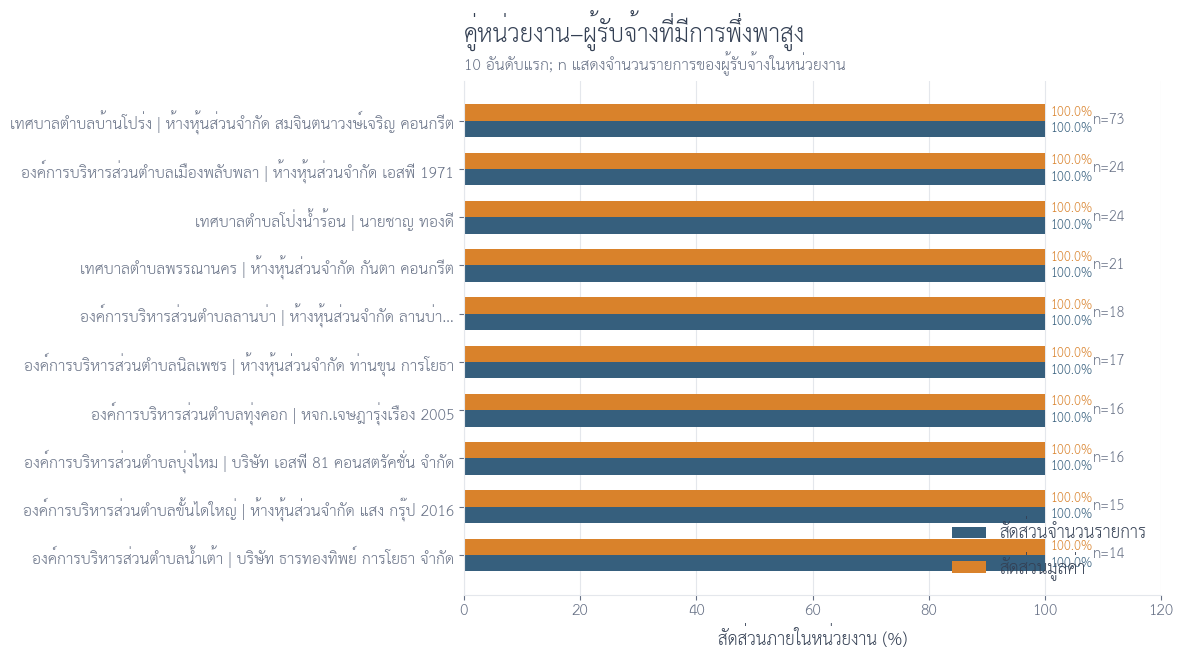

,ชื่อหน่วยงาน,ผู้รับจ้าง,จำนวนรายการของผู้รับจ้าง,สัดส่วนจำนวนรายการ (%),สัดส่วนมูลค่า (%)
0,เทศบาลตำบลบ้านโปร่ง,ห้างหุ้นส่วนจำกัด สมจินตนาวงษ์เจริญ คอนกรีต,73,100.00,100.00
9,องค์การบริหารส่วนตำบลเมืองพลับพลา,ห้างหุ้นส่วนจำกัด เอสพี 1971,24,100.00,100.00
10,เทศบาลตำบลโป่งน้ำร้อน,นายชาญ ทองดี,24,100.00,100.00
13,เทศบาลตำบลพรรณานคร,ห้างหุ้นส่วนจำกัด กันตา คอนกรีต,21,100.00,100.00
18,องค์การบริหารส่วนตำบลลานบ่า,ห้างหุ้นส่วนจำกัด ลานบ่า คอนสตรัคชั่น,18,100.00,100.00
22,องค์การบริหารส่วนตำบลนิลเพชร,ห้างหุ้นส่วนจำกัด ท่านขุน การโยธา,17,100.00,100.00
27,องค์การบริหารส่วนตำบลทุ่งคอก,หจก.เจษฎารุ่งเรือง 2005,16,100.00,100.00
28,องค์การบริหารส่วนตำบลบุ่งไหม,บริษัท เอสพี 81 คอนสตรัคชั่น จำกัด,16,100.00,100.00
31,องค์การบริหารส่วนตำบลขั้นไดใหญ่,ห้างหุ้นส่วนจำกัด แสง กรุ๊ป 2016,15,100.00,100.00
33,องค์การบริหารส่วนตำบลน้ำเต้า,บริษัท ธารทองทิพย์ การโยธา จำกัด,14,100.00,100.00


In [13]:
top_dependency_pairs = (
    pattern2_pairs
    .sort_values(
        [
            'สัดส่วนจำนวนรายการ (%)',
            'จำนวนรายการของผู้รับจ้าง',
            'สัดส่วนมูลค่า (%)'
        ],
        ascending=False
    )
    .head(10)
    .copy()
)

top_dependency_pairs['คู่หน่วยงาน–ผู้รับจ้าง'] = [
    shorten(
        f'{agency} | {supplier}',
        width=66,
        placeholder='…'
    )
    for agency, supplier in zip(
        top_dependency_pairs[agency_column],
        top_dependency_pairs['ผู้รับจ้าง']
    )
]

plot_data = top_dependency_pairs.iloc[::-1].reset_index(drop=True)
y_position = np.arange(len(plot_data))
bar_height = 0.34

fig, ax = plt.subplots(figsize=FIG_SIZE)

count_bars = ax.barh(
    y_position - bar_height / 2,
    plot_data['สัดส่วนจำนวนรายการ (%)'],
    height=bar_height,
    color=COLORS['primary'],
    label='สัดส่วนจำนวนรายการ'
)
value_bars = ax.barh(
    y_position + bar_height / 2,
    plot_data['สัดส่วนมูลค่า (%)'],
    height=bar_height,
    color=COLORS['highlight'],
    label='สัดส่วนมูลค่า'
)

ax.bar_label(
    count_bars,
    labels=[f'{value:.1f}%' for value in plot_data['สัดส่วนจำนวนรายการ (%)']],
    padding=4,
    fontsize=9,
    color=COLORS['primary']
)
ax.bar_label(
    value_bars,
    labels=[f'{value:.1f}%' for value in plot_data['สัดส่วนมูลค่า (%)']],
    padding=4,
    fontsize=9,
    color=COLORS['highlight']
)

for y, count, maximum_share in zip(
    y_position,
    plot_data['จำนวนรายการของผู้รับจ้าง'],
    plot_data[['สัดส่วนจำนวนรายการ (%)', 'สัดส่วนมูลค่า (%)']].max(axis=1)
):
    ax.text(
        min(maximum_share + 8, 112),
        y,
        f'n={count:,.0f}',
        va='center',
        ha='left',
        fontsize=10,
        color=COLORS['muted']
    )

ax.set_yticks(y_position)
ax.set_yticklabels(plot_data['คู่หน่วยงาน–ผู้รับจ้าง'])
ax.set_title('คู่หน่วยงาน–ผู้รับจ้างที่มีการพึ่งพาสูง', pad=28)
add_subtitle(ax, '10 อันดับแรก; n แสดงจำนวนรายการของผู้รับจ้างในหน่วยงาน')
ax.set_xlabel('สัดส่วนภายในหน่วยงาน (%)')
ax.set_ylabel('')
ax.set_xlim(0, 120)
ax.legend(frameon=False, loc='lower right')
clean_axis(ax, grid_axis='x')

fig.tight_layout()
save_figure(fig, 'fig05_06_pattern2_top10_dependency_pairs')
plt.show()

display(
    top_dependency_pairs[[
        agency_column,
        'ผู้รับจ้าง',
        'จำนวนรายการของผู้รับจ้าง',
        'สัดส่วนจำนวนรายการ (%)',
        'สัดส่วนมูลค่า (%)'
    ]]
)


## Story 8 — Pattern 1 และ Pattern 2 ซ้อนทับกันอย่างไร

Pattern 1 มองความถี่ของรายการใกล้เพดานในคู่เดิม ส่วน Pattern 2 มองการกระจุกตัวของผู้รับจ้างภายในหน่วยงาน ทั้งสองเป็นคนละมิติ จึงคำนวณแยกกันแล้วเลือกเฉพาะรายการที่เข้าเงื่อนไขพร้อมกัน


Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig05_07_pattern_intersection_journey.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig05_07_pattern_intersection_journey.svg


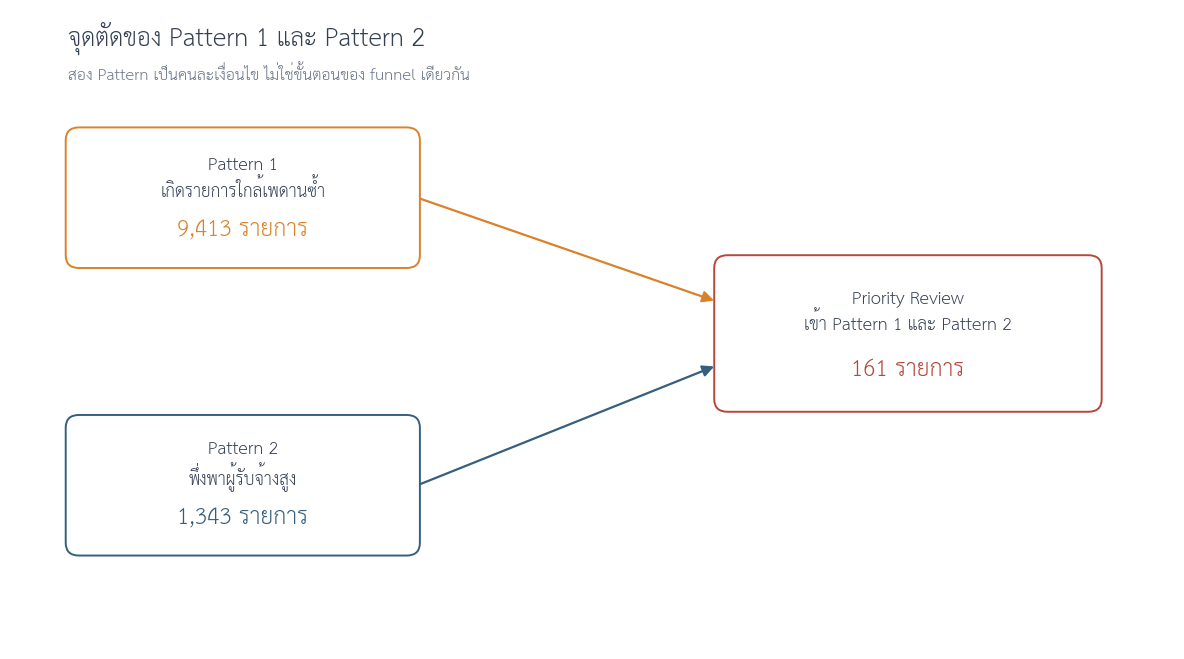

In [14]:
pattern1_count = int(contract_flags['flag_pattern_1'].sum())
pattern2_count = int(contract_flags['flag_pattern_2'].sum())
priority_count = int(contract_flags['priority_review'].sum())

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis('off')


def add_box(x, y, width, height, title, value, color):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle='round,pad=0.03,rounding_size=0.16',
        linewidth=1.4,
        edgecolor=color,
        facecolor='white'
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2,
        y + height * 0.64,
        title,
        ha='center',
        va='center',
        fontsize=12,
        color=COLORS['text']
    )
    ax.text(
        x + width / 2,
        y + height * 0.26,
        f'{value:,.0f} รายการ',
        ha='center',
        va='center',
        fontsize=16,
        fontweight='semibold',
        color=color
    )


def add_arrow(start, end, color=COLORS['neutral']):
    ax.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle='-|>',
            mutation_scale=17,
            linewidth=1.6,
            color=color,
            connectionstyle='arc3,rad=0.0'
        )
    )


add_box(
    0.7, 4.8, 4.2, 1.7,
    'Pattern 1\nเกิดรายการใกล้เพดานซ้ำ',
    pattern1_count,
    COLORS['highlight']
)
add_box(
    0.7, 1.2, 4.2, 1.7,
    'Pattern 2\nพึ่งพาผู้รับจ้างสูง',
    pattern2_count,
    COLORS['primary']
)
add_box(
    8.5, 3.0, 4.6, 1.9,
    'Priority Review\nเข้า Pattern 1 และ Pattern 2',
    priority_count,
    COLORS['risk']
)

add_arrow((4.9, 5.65), (8.5, 4.35), COLORS['highlight'])
add_arrow((4.9, 2.05), (8.5, 3.55), COLORS['primary'])

ax.text(
    0.7,
    7.55,
    'จุดตัดของ Pattern 1 และ Pattern 2',
    fontsize=17,
    fontweight='semibold',
    color=COLORS['text'],
    ha='left'
)
ax.text(
    0.7,
    7.12,
    'สอง Pattern เป็นคนละเงื่อนไข ไม่ใช่ขั้นตอนของ funnel เดียวกัน',
    fontsize=11,
    color=COLORS['muted'],
    ha='left'
)

fig.tight_layout()
save_figure(fig, 'fig05_07_pattern_intersection_journey')
plt.show()


## Story 9 — คู่หน่วยงาน–ผู้รับจ้างใดควรเปิดเอกสารก่อน

จัดอันดับรายการที่เข้า Pattern 1 และ Pattern 2 พร้อมกันตามจำนวนรายการของคู่หน่วยงาน–ผู้รับจ้าง เพื่อกำหนดลำดับการเปิดเอกสาร ไม่ใช่จัดอันดับความทุจริต ตารางใต้ภาพใช้ Top 10 ชุดเดียวกับ visual


Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig05_08_priority_top10_pairs.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig05_08_priority_top10_pairs.svg


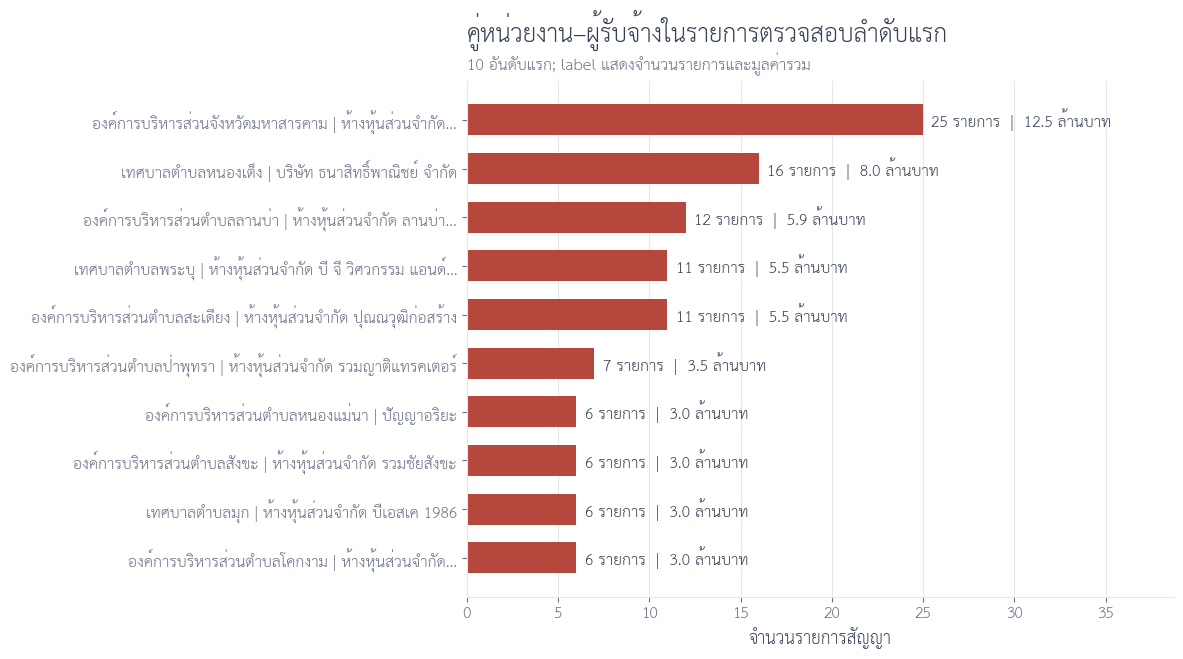

,ลำดับ,ชื่อหน่วยงาน,ชื่อผู้ชนะการเสนอราคา,จังหวัด,จำนวนรายการตรวจสอบ,มูลค่ารวม (บาท)
0,1,องค์การบริหารส่วนจังหวัดมหาสารคาม,ห้างหุ้นส่วนจำกัด เจริญทรัพย์มหาสารคาม ก่อสร้าง,มหาสารคาม,25,"12,454,000.00"
1,2,เทศบาลตำบลหนองเต็ง,บริษัท ธนาสิทธิ์พาณิชย์ จำกัด,บุรีรัมย์,16,"7,952,000.00"
2,3,องค์การบริหารส่วนตำบลลานบ่า,ห้างหุ้นส่วนจำกัด ลานบ่า คอนสตรัคชั่น,เพชรบูรณ์,12,"5,914,000.00"
3,4,เทศบาลตำบลพระบุ,ห้างหุ้นส่วนจำกัด บี จี วิศวกรรม แอนด์ คอนสตรัคชั่น,ขอนแก่น,11,"5,475,400.00"
4,5,องค์การบริหารส่วนตำบลสะเดียง,ห้างหุ้นส่วนจำกัด ปุณณวุฒิก่อสร้าง,เพชรบูรณ์,11,"5,454,000.00"
5,6,องค์การบริหารส่วนตำบลป่าพุทรา,ห้างหุ้นส่วนจำกัด รวมญาติแทรคเตอร์,กำแพงเพชร,7,"3,465,500.00"
6,7,องค์การบริหารส่วนตำบลหนองแม่นา,ปัญญาอริยะ,เพชรบูรณ์,6,"2,997,000.00"
7,8,องค์การบริหารส่วนตำบลสังขะ,ห้างหุ้นส่วนจำกัด รวมชัยสังขะ,สุรินทร์,6,"2,982,400.00"
8,9,เทศบาลตำบลมุก,ห้างหุ้นส่วนจำกัด บีเอสเค 1986,มุกดาหาร,6,"2,969,200.00"
9,10,องค์การบริหารส่วนตำบลโคกงาม,ห้างหุ้นส่วนจำกัด เบ๊นซ์วัสดุก่อสร้าง,เลย,6,"2,962,000.00"


In [15]:
priority_pair_summary = (
    priority_contracts
    .groupby(
        [agency_column, supplier_id_column],
        dropna=False
    )
    .agg({
        supplier_name_column: 'first',
        province_column: 'first',
        contract_column: 'size',
        contract_value_column: 'sum'
    })
    .reset_index()
    .rename(columns={
        contract_column: 'จำนวนรายการตรวจสอบ',
        contract_value_column: 'มูลค่ารวม (บาท)'
    })
    .sort_values(
        ['จำนวนรายการตรวจสอบ', 'มูลค่ารวม (บาท)'],
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

priority_pair_summary.insert(
    0,
    'ลำดับ',
    np.arange(1, len(priority_pair_summary) + 1)
)

priority_pair_summary['คู่หน่วยงาน–ผู้รับจ้าง'] = [
    shorten(
        f'{agency} | {supplier}',
        width=66,
        placeholder='…'
    )
    for agency, supplier in zip(
        priority_pair_summary[agency_column],
        priority_pair_summary[supplier_name_column]
    )
]

plot_data = priority_pair_summary.iloc[::-1]

fig, ax = plt.subplots(figsize=FIG_SIZE)

bars = ax.barh(
    plot_data['คู่หน่วยงาน–ผู้รับจ้าง'],
    plot_data['จำนวนรายการตรวจสอบ'],
    color=COLORS['risk'],
    height=0.64
)

labels = [
    f'{count:,.0f} รายการ  |  {value / 1_000_000:,.1f} ล้านบาท'
    for count, value in zip(
        plot_data['จำนวนรายการตรวจสอบ'],
        plot_data['มูลค่ารวม (บาท)']
    )
]

ax.bar_label(
    bars,
    labels=labels,
    padding=6,
    fontsize=11,
    color=COLORS['text']
)

ax.set_title('คู่หน่วยงาน–ผู้รับจ้างในรายการตรวจสอบลำดับแรก', pad=28)
add_subtitle(ax, '10 อันดับแรก; label แสดงจำนวนรายการและมูลค่ารวม')
ax.set_xlabel('จำนวนรายการสัญญา')
ax.set_ylabel('')
ax.set_xlim(0, plot_data['จำนวนรายการตรวจสอบ'].max() * 1.55)
clean_axis(ax, grid_axis='x')

fig.tight_layout()
save_figure(fig, 'fig05_08_priority_top10_pairs')
plt.show()

priority_table = priority_pair_summary[[
    'ลำดับ',
    agency_column,
    supplier_name_column,
    province_column,
    'จำนวนรายการตรวจสอบ',
    'มูลค่ารวม (บาท)'
]].copy()

display(priority_table)


## สรุปลำดับการใช้ภาพ

| ลำดับเรื่อง | Figure | หน้าที่ในเรื่อง |
|---:|---|---|
| 1 | ตาราง Data journey | แสดงข้อมูลตั้งต้น การเลือกงานก่อสร้าง การตัดรหัส D และ grain ที่ใช้วิเคราะห์ |
| 2 | `fig05_01_construction_overview` | แสดงภาพรวมช่วงวงเงินและวิธีจัดซื้อของงานก่อสร้าง |
| 3 | `fig05_02_contract_distribution_around_500k` | ขยายดูการกระจุกบริเวณ 500,000 บาท |
| 4 | `fig05_03_method_near_500k` | ตรวจว่ารายการใกล้เพดานสัมพันธ์กับวิธีใด |
| 5 | `fig05_04_pattern_study_scope` | แสดงขอบเขตศึกษาแบบ subset ซ้อนกัน |
| 6 | `fig05_05_pattern1_top10_repeated_pairs` | แสดง Pattern 1 Top 10 |
| 7 | `fig05_06_pattern2_top10_dependency_pairs` | แสดง Pattern 2 Top 10 |
| 8 | `fig05_07_pattern_intersection_journey` | แสดงจุดตัดของ Pattern 1 และ Pattern 2 |
| 9 | `fig05_08_priority_top10_pairs` | แสดง Priority Review Top 10 พร้อมตาราง |

ภาพทั้งหมดบันทึกเป็น PNG และ SVG ในโฟลเดอร์ `project_1_dads5001/figure`
